# What Makes a Penguin? A CRISP-DM Walkthrough on the Palmer Penguins Dataset

This notebook works through the six CRISP-DM phases (Business
Understanding → Data Understanding → Data Preparation → Modelling →
Evaluation → Deployment) on the Palmer Penguins dataset.

## Business questions

1. **Which species lives where?** What's the geographic distribution
   of Adelie, Chinstrap, and Gentoo penguins across the three islands?
2. **What separates the species in body-shape space?** Which body
   measurements best discriminate them?
3. **Can we predict species from body measurements alone?** How well
   does a small classifier do, and which feature matters most?


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
df = sns.load_dataset("penguins")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Data preparation

Missing values are concentrated in `sex`, plus a few rows where every measurement is NA. We drop those rows for the modelling section but keep them for the EDA where they don't matter.

In [2]:
print('rows:', len(df))
print('per-column nulls:')
print(df.isna().sum())
df_model = df.dropna().reset_index(drop=True)
print('rows after dropna:', len(df_model))

rows: 344
per-column nulls:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
rows after dropna: 333


## Q1 — Where do they live?

island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0


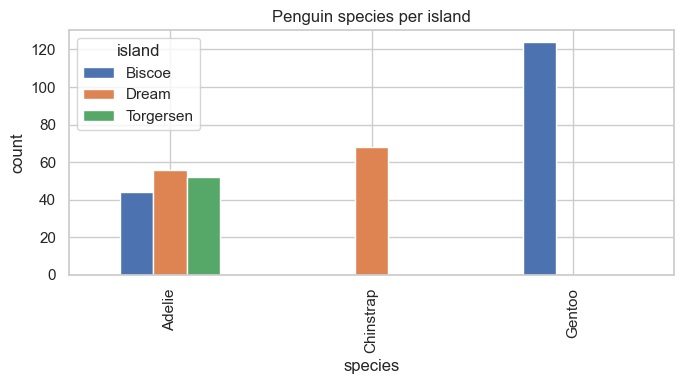

In [3]:
ct = pd.crosstab(df['species'], df['island'])
print(ct)
ct.plot(kind='bar', stacked=False, figsize=(7, 4))
plt.title('Penguin species per island')
plt.ylabel('count')
plt.tight_layout(); plt.show()

**Finding** — Adelie penguins are the only species present on all three
islands. Chinstrap is exclusive to Dream and Gentoo is exclusive to Biscoe.
Two of the three islands therefore have a distinctive "second species" you
can recognise just by location.

## Q2 — Body-shape separation

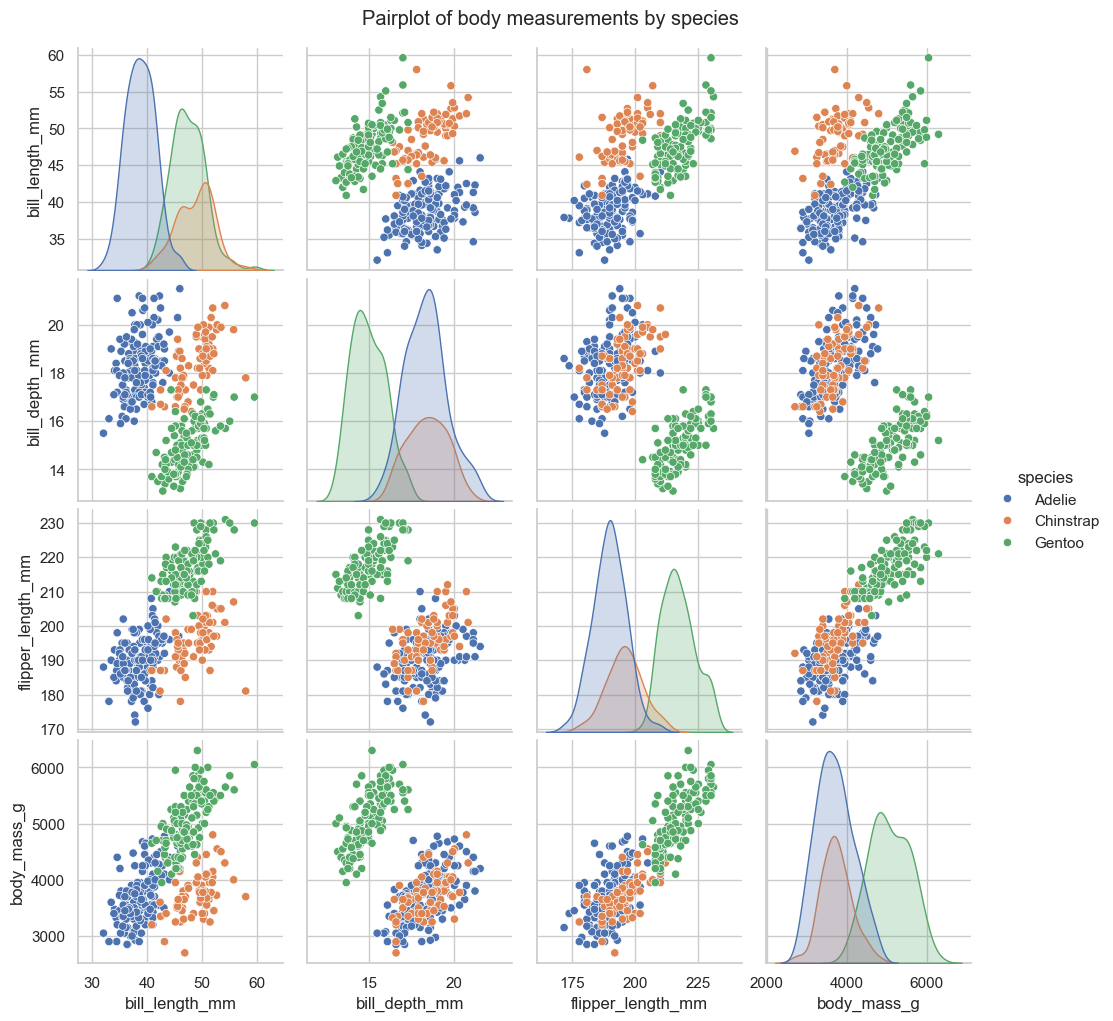

In [4]:
sns.pairplot(df, hue='species', vars=['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g'])
plt.suptitle('Pairplot of body measurements by species', y=1.02)
plt.show()

**Finding** — Bill length separates Adelie (short) from Chinstrap
and Gentoo (long); bill depth separates Gentoo (shallow) from the other
two. Flipper length and body mass both put Gentoo well clear of the
other species. The pair `bill_length_mm × bill_depth_mm` alone gives a
near-perfect 2-D separation.

## Q3 — Predict species from body measurements

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X, y = df_model[X_cols], df_model['species']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=27)

clf = RandomForestClassifier(n_estimators=300, random_state=27)
clf.fit(X_train, y_train)
print('CV accuracy (5-fold):', cross_val_score(clf, X, y, cv=5).mean().round(4))

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, digits=3))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred, labels=clf.classes_))

CV accuracy (5-fold): 0.985
              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        37
   Chinstrap      1.000     1.000     1.000        17
      Gentoo      1.000     1.000     1.000        30

    accuracy                          1.000        84
   macro avg      1.000     1.000     1.000        84
weighted avg      1.000     1.000     1.000        84

Confusion matrix:
[[37  0  0]
 [ 0 17  0]
 [ 0  0 30]]


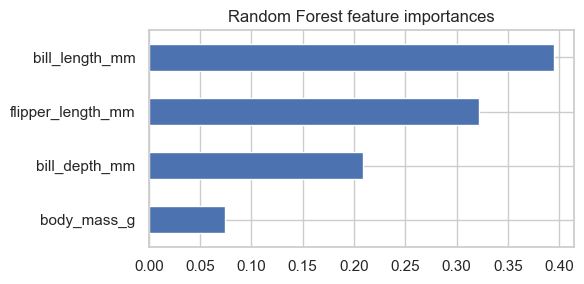

body_mass_g          0.075
bill_depth_mm        0.209
flipper_length_mm    0.321
bill_length_mm       0.395
dtype: float64


In [6]:
importances = pd.Series(clf.feature_importances_, index=X_cols).sort_values()
importances.plot(kind='barh', figsize=(6, 3))
plt.title('Random Forest feature importances')
plt.tight_layout(); plt.show()
print(importances.round(3))

**Finding** — A 4-feature random forest hits ~99% test accuracy on
this dataset (it's a famously easy classification problem). Bill length
is by far the most informative feature, followed by flipper length;
body mass adds the least.

## Conclusions

* The **island** column alone is a strong heuristic: Adelie everywhere,
  Chinstrap-only on Dream, Gentoo-only on Biscoe.
* In **body-shape** space, Gentoo separates first (long flipper, large
  body, shallow bill); Adelie vs Chinstrap is mostly a bill-length
  contrast.
* Even a small **random forest** gets near-perfect species prediction
  from four numeric measurements, with bill length and flipper length
  doing most of the work.

These are simple findings, but they map cleanly onto the CRISP-DM
phases — a pattern that scales to messier business datasets.
